ADF stationarity p-values:
1M: 1.235e-29
3M: 0
6M: 1.172e-12
12M: 0
2Y: 2.871e-23
3Y: 2.562e-12
5Y: 0
10Y: 0
20Y: 0
30Y: 0
GDP: 1.198e-23
CPI: 1.626e-16
Selected VAR lag order: 1


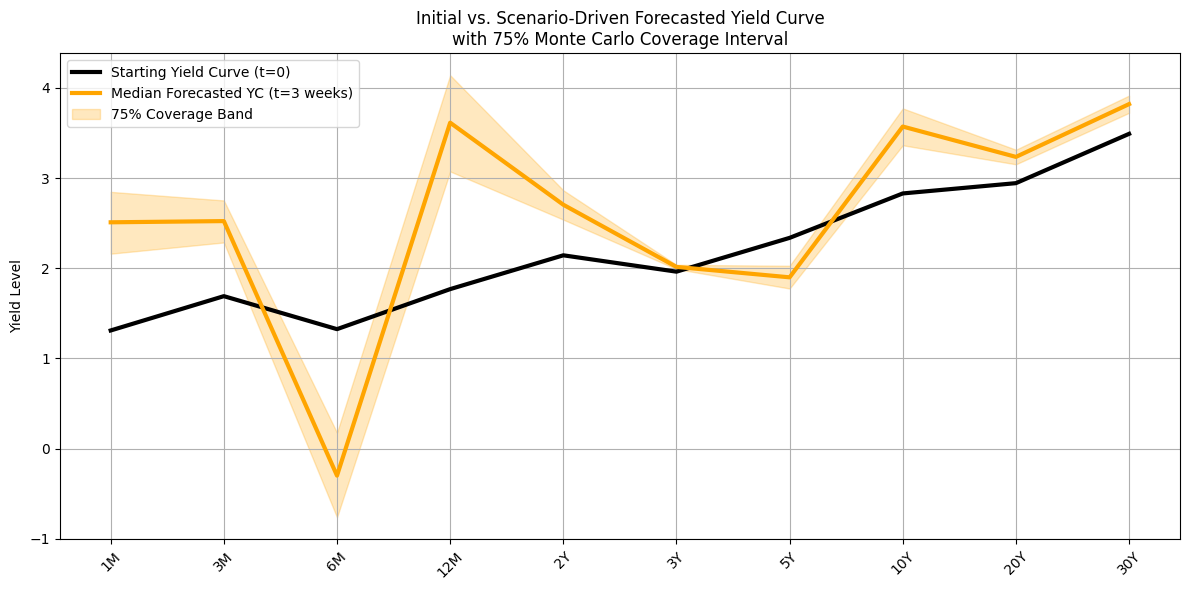

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# SYNTHETIC DATA GENERATION (REALISTIC YIELD CURVES)
# ======================================================

np.random.seed(42)
T = 500

maturities = ['1M','3M','6M','12M','2Y','3Y','5Y','10Y','20Y','30Y']
features = maturities + ['GDP','CPI']

data = pd.DataFrame(
    index=pd.date_range(start='2000-01-01', periods=T, freq='W'),
    columns=features
)

# ------------------------------------------------------
# 1. TARGET MEAN YIELD CURVE
# ------------------------------------------------------
mu_yields = np.array([
    1.5,   # 1M
    1.6,   # 3M
    1.7,   # 6M
    1.8,   # 12M
    2.0,   # 2Y
    2.2,   # 3Y
    2.5,   # 5Y
    2.8,   # 10Y
    3.1,   # 20Y
    3.3    # 30Y
])

# ------------------------------------------------------
# 2. Shock covariance across maturities
# ------------------------------------------------------
cov_matrix = np.diag([0.01]*10) + 0.004  # moderate correlation

# ------------------------------------------------------
# 3. Mean-reverting AR(1) process for yields
# ------------------------------------------------------
phi = 0.97  # high persistence, but mean reverting

y = np.zeros((T, 10))
y[0] = mu_yields  # start at long-run mean

for t in range(1, T):
    shock = np.random.multivariate_normal(
        mean=np.zeros(10),
        cov=cov_matrix
    )
    # AR(1): y_t = mu + phi*(y_{t-1} - mu) + noise
    y[t] = mu_yields + phi * (y[t-1] - mu_yields) + shock

data[maturities] = y

# ------------------------------------------------------
# 4. GDP and CPI AR(1) macro series
# ------------------------------------------------------

# GDP long-run level and dynamics
mu_gdp = 0.02
phi_gdp = 0.9
sigma_gdp = 0.005

gdp = np.zeros(T)
gdp[0] = mu_gdp
for t in range(1, T):
    gdp[t] = mu_gdp + phi_gdp * (gdp[t-1] - mu_gdp) + np.random.normal(0, sigma_gdp)

# CPI long-run inflation
mu_cpi = 0.015
phi_cpi = 0.92
sigma_cpi = 0.003

cpi = np.zeros(T)
cpi[0] = mu_cpi
for t in range(1, T):
    cpi[t] = mu_cpi + phi_cpi * (cpi[t-1] - mu_cpi) + np.random.normal(0, sigma_cpi)

data['GDP'] = gdp
data['CPI'] = cpi


# ======================================================
# 1. DIFFERENCING + ADF TESTING
# ======================================================
diff_data = data.diff().dropna()

print("ADF stationarity p-values:")
for col in diff_data.columns:
    pval = adfuller(diff_data[col])[1]
    print(f"{col}: {pval:.4g}")

# ======================================================
# 2. FIT VAR MODEL
# ======================================================
model = VAR(diff_data)
lag_select = model.select_order(maxlags=4)
lag_order = lag_select.selected_orders["aic"]

# Force lag_order >= 1 for forecasting
lag_order = max(1, lag_order)
print(f"Selected VAR lag order: {lag_order}")

var_results = model.fit(lag_order)

# ======================================================
# 3. MONTE CARLO GDP-ONLY STOCHASTIC FORECAST
# ======================================================
T_forecast = 21        # 3 weeks
n_sim = 5000

GDP_index = diff_data.columns.get_loc("GDP")

# last p observations to seed recursive forecasting
Y_history0 = diff_data.values[-lag_order:, :]

GDP_target_growth = -0.10
GDP_drift_per_step = GDP_target_growth / T_forecast
sigma_gdp = 0.005

simulated_yields = np.zeros((n_sim, T_forecast, len(maturities)))
# Storage for all GDP paths (levels after differencing integration)
all_gdp_paths = np.zeros((n_sim, T_forecast))

for sim in range(n_sim):

    # Initialize rolling window
    Y_hist = Y_history0.copy()

    # Generate GDP path
    GDP_path = [Y_hist[-1, GDP_index]]
    for _ in range(T_forecast):
        g = GDP_drift_per_step + np.random.normal(0, sigma_gdp)
        GDP_path.append(GDP_path[-1] + g)
    GDP_path = np.array(GDP_path[1:])
    all_gdp_paths[sim, :] = GDP_path

    # Simulate forecast
    for t in range(T_forecast):

        # Construct regressor (1 + stacked lags)
        lag_vec = Y_hist.flatten()
        x = np.insert(lag_vec, 0, 1)    # add intercept

        # Deterministic VAR forecast
        next_step = var_results.params.values.T @ x

        # Overwrite GDP with scenario path
        next_step[GDP_index] = GDP_path[t]

        # Store yields
        simulated_yields[sim, t, :] = next_step[:len(maturities)]

        # Roll window
        Y_hist = np.vstack([Y_hist, next_step])[-lag_order:, :]

# ======================================================
# 4. CONVERT FORECASTED ΔYIELDS INTO LEVEL YIELDS
# ======================================================

# Last observed yield levels (not differenced)
last_yield_levels = data[maturities].iloc[-1].values   # shape: (10,)

# Convert all 1000 simulated Δy paths into yield levels
cum_yields = np.zeros_like(simulated_yields)

for sim in range(n_sim):
    # First step = last level + first predicted delta
    cum_yields[sim, 0, :] = last_yield_levels + simulated_yields[sim, 0, :]
    # Subsequent steps accumulate differences
    for t in range(1, T_forecast):
        cum_yields[sim, t, :] = cum_yields[sim, t-1, :] + simulated_yields[sim, t, :]

# Median yield level forecast
median_level_path = np.median(cum_yields, axis=0)  # shape: (21, 10)
final_median_yield_curve = median_level_path[-1]   # final 3-week forecasted YC

# ======================================================
# 4b. Compute 75% Coverage Interval (12.5th–87.5th percentiles)
# ======================================================

lower_band = np.percentile(cum_yields[:, -1, :], 12.5, axis=0)
upper_band = np.percentile(cum_yields[:, -1, :], 87.5, axis=0)

# These now represent yield curves at t=3 weeks:
# lower_band[j] = 12.5th percentile yield for maturity j
# upper_band[j] = 87.5th percentile yield for maturity j


# ======================================================
# 5. PLOT INITIAL VS FORECASTED CURVE + 75% COVERAGE
# ======================================================

plt.figure(figsize=(12,6))

x = np.arange(len(maturities))

# Starting curve
plt.plot(x, last_yield_levels, 
         label="Starting Yield Curve (t=0)", 
         linewidth=3, color="black")

# Median forecasted curve
plt.plot(x, final_median_yield_curve, 
         label="Median Forecasted YC (t=3 weeks)", 
         linewidth=3, color="orange")

# 75% coverage band (12.5th–87.5th percentile)
plt.fill_between(x, lower_band, upper_band, 
                 color="orange", alpha=0.25,
                 label="75% Coverage Band")

plt.xticks(x, maturities, rotation=45)
plt.ylabel("Yield Level")
plt.title("Initial vs. Scenario-Driven Forecasted Yield Curve\nwith 75% Monte Carlo Coverage Interval")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


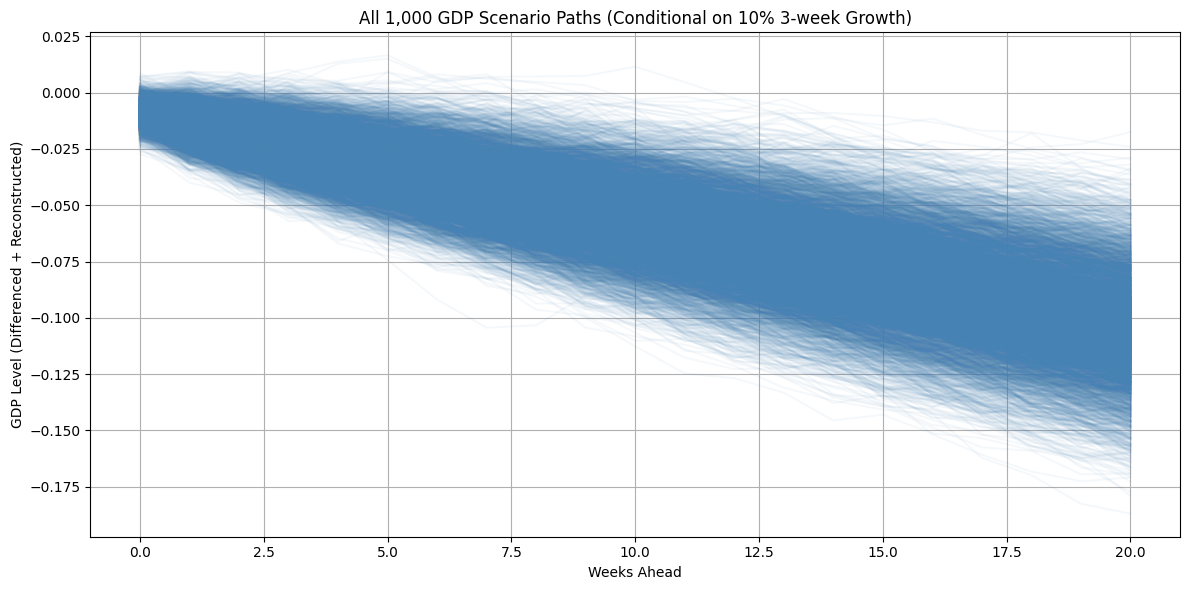

In [12]:
# ======================================================
# PLOT 1: All Simulated GDP Conditional Paths
# ======================================================

plt.figure(figsize=(12,6))
for sim in range(n_sim):
    plt.plot(all_gdp_paths[sim], color="steelblue", alpha=0.05)

plt.title("All 1,000 GDP Scenario Paths (Conditional on 10% 3-week Growth)")
plt.xlabel("Weeks Ahead")
plt.ylabel("GDP Level (Differenced + Reconstructed)")
plt.grid(True)
plt.tight_layout()
plt.show()


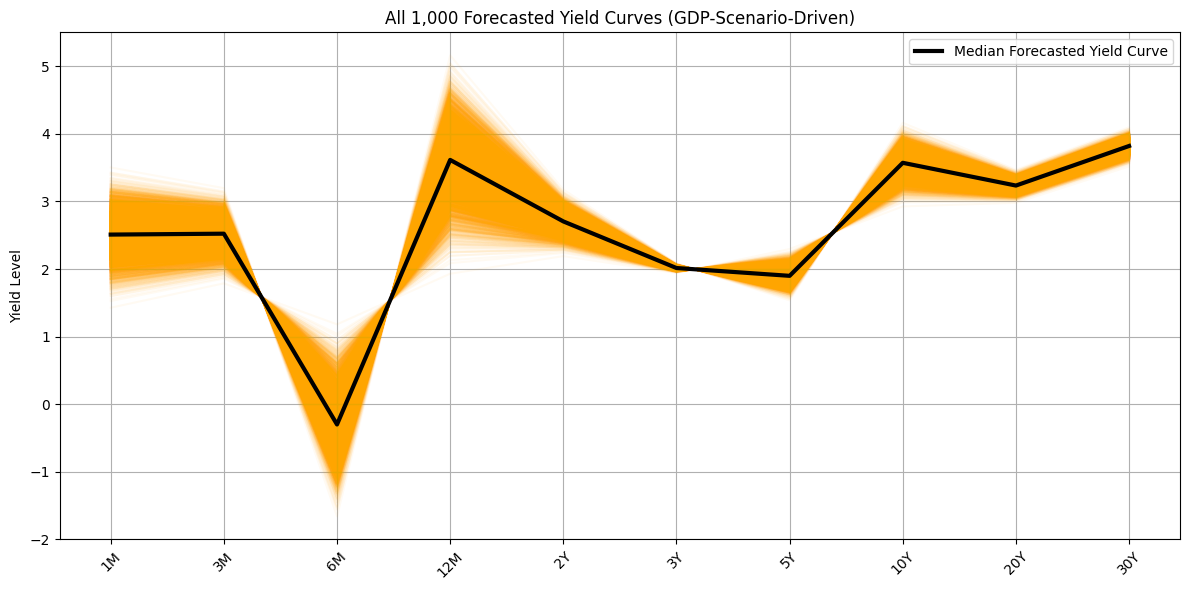

In [13]:
final_yc_all = cum_yields[:, -1, :]    # shape (1000, 10)
# ======================================================
# PLOT 2: All Forecasted Yield Curves at Horizon
# ======================================================

plt.figure(figsize=(12,6))
x = np.arange(len(maturities))

for sim in range(n_sim):
    plt.plot(x, final_yc_all[sim], color="orange", alpha=0.05)

plt.plot(x, final_median_yield_curve, color="black", linewidth=3,
         label="Median Forecasted Yield Curve")

plt.xticks(x, maturities, rotation=45)
plt.ylabel("Yield Level")
plt.title("All 1,000 Forecasted Yield Curves (GDP-Scenario-Driven)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


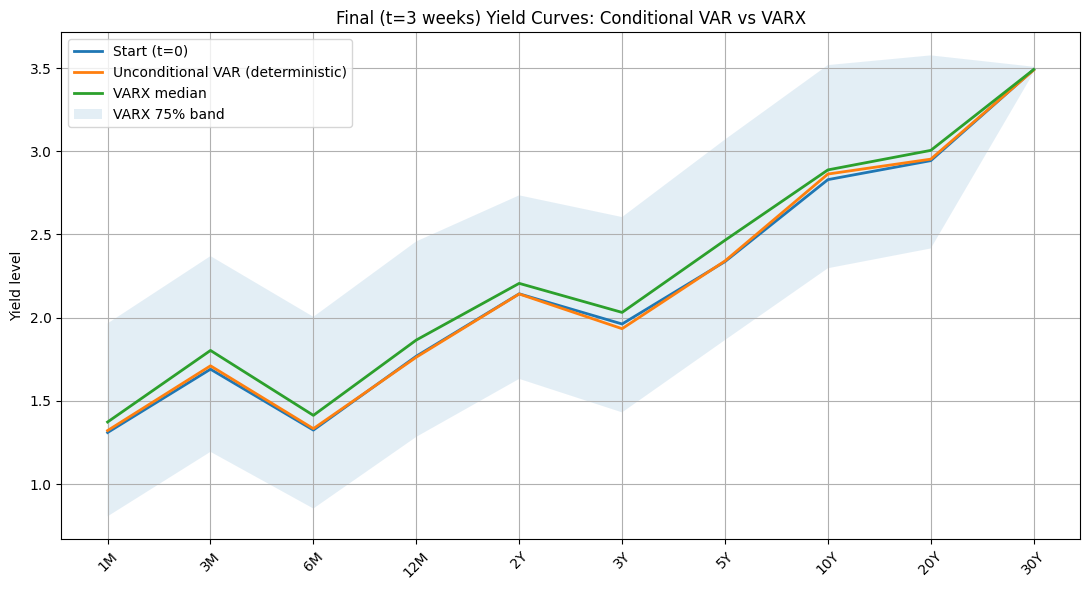

Maturity    Start  Deterministic_VAR  Median_VARX  VARX_lower12.5  VARX_upper87.5
      1M 1.309468           1.321259     1.372589        0.805358        1.965325
      3M 1.690161           1.710492     1.802865        1.193493        2.370163
      6M 1.324083           1.332796     1.412620        0.852557        2.005041
     12M 1.768229           1.762244     1.865449        1.283309        2.458311
      2Y 2.143350           2.142365     2.206116        1.631966        2.735333
      3Y 1.961929           1.933682     2.031537        1.430623        2.604720
      5Y 2.336965           2.340931     2.465191        1.865390        3.071064
     10Y 2.829688           2.863306     2.888257        2.297096        3.518376
     20Y 2.943900           2.952900     3.005637        2.415941        3.576659
     30Y 3.490988           3.488753     3.491559        3.474318        3.508321


In [ ]:
"""
Two-method comparison:
  - Approach A: Conditional VAR Monte Carlo (force GDP scenario while sampling conditional residuals)
  - Approach B: VARX (treat GDP as exogenous) and simulate with exogenous forced GDP path

Notes:
  - The VAR/VARX are estimated on first differences (Δ), like your original script.
  - Scenario: "10% growth in GDP over horizon" is interpreted as a level target. We compute a linear-in-level path
    from last observed level to the 10%-higher target and convert to Δs for use in the Δ-domain models.
  - If you prefer log-percentage targets, change the conversion to log and use log-differences consistently.
  - n_sim reduced for speed; increase as needed.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ---------------- Synthetic data (from user) ----------------
T = 500
maturities = ['1M','3M','6M','12M','2Y','3Y','5Y','10Y','20Y','30Y']
features = maturities + ['GDP','CPI']

dates = pd.date_range(start='2000-01-01', periods=T, freq='W')
data = pd.DataFrame(index=dates, columns=features, dtype=float)

mu_yields = np.array([1.5,1.6,1.7,1.8,2.0,2.2,2.5,2.8,3.1,3.3])
cov_matrix = np.diag([0.01]*10) + 0.004

phi = 0.97
y = np.zeros((T, 10))
y[0] = mu_yields
for t in range(1, T):
    shock = np.random.multivariate_normal(mean=np.zeros(10), cov=cov_matrix)
    y[t] = mu_yields + phi*(y[t-1] - mu_yields) + shock
data[maturities] = y

# GDP & CPI AR(1)
mu_gdp = 0.02; phi_gdp = 0.9; sigma_gdp = 0.005
gdp = np.zeros(T); gdp[0] = mu_gdp
for t in range(1, T):
    gdp[t] = mu_gdp + phi_gdp*(gdp[t-1] - mu_gdp) + np.random.normal(0, sigma_gdp)
data['GDP'] = gdp

mu_cpi = 0.015; phi_cpi = 0.92; sigma_cpi = 0.003
cpi = np.zeros(T); cpi[0] = mu_cpi
for t in range(1, T):
    cpi[t] = mu_cpi + phi_cpi*(cpi[t-1] - mu_cpi) + np.random.normal(0, sigma_cpi)
data['CPI'] = cpi

# ---------------- Prepare Δ data and estimate VAR ----------------
diff_data = data.diff().dropna()

# quick stationarity check (ADF p-values)
adf_pvals = {col: adfuller(diff_data[col])[1] for col in diff_data.columns}

model = VAR(diff_data)
lag_select = model.select_order(maxlags=4)
lag_order = lag_select.selected_orders["aic"]
lag_order = max(1, lag_order)
var_res = model.fit(lag_order)

# useful constants
shocked_feature = '1M'
k = diff_data.shape[1]
GDP_idx = list(diff_data.columns).index(shocked_feature)
m = len(maturities)
last_yield_levels = data[maturities].iloc[-1].values
last_gdp_level = data[shocked_feature].iloc[-1]

# ---------------- Scenario: 10% level growth over horizon ----------------
T_forecast = 21
n_sim = 2000  # change to 5000 if you want; may be slower

# Interpret as level increase: target level = last_level * 1.10
target_level = last_gdp_level * 1.25
# Linear level path from current level to target over T_forecast steps
level_path = np.linspace(last_gdp_level, target_level, T_forecast+1)[1:]
# Convert to ΔGDP series (units matching diff_data)
forced_delta_gdp_series = np.diff(np.concatenate([[last_gdp_level], level_path]))  # length T_forecast

# seed lags for forecasting (Δ data)
Y_history0 = diff_data.values[-lag_order:, :]

# ---------------- Approach A: Conditional VAR simulation ----------------
# Convert residual covariance to numpy array to allow integer indexing
"""Sigma_u = var_res.sigma_u.values      # <-- FIX
other_idx = [i for i in range(k) if i != GDP_idx]

Sigma_GG = Sigma_u[GDP_idx, GDP_idx]
Sigma_OG = Sigma_u[np.ix_(other_idx, [GDP_idx])]
Sigma_GO = Sigma_u[np.ix_([GDP_idx], other_idx)]
Sigma_OO = Sigma_u[np.ix_(other_idx, other_idx)]

Sigma_O_given_G = Sigma_OO - (Sigma_OG @ Sigma_GO) / Sigma_GG

simulated_yields_cond = np.zeros((n_sim, T_forecast, m))
all_gdp_paths_cond = np.zeros((n_sim, T_forecast))

for sim in range(n_sim):
    # reproducible per-sim but different across sims
    rng = np.random.RandomState(100 + sim)
    Y_hist = Y_history0.copy()
    for t in range(T_forecast):
        lag_vec = Y_hist.flatten()
        x = np.insert(lag_vec, 0, 1.0)        # intercept + stacked lags
        deterministic_next = var_res.params.values.T @ x  # shape (k,)
        forced_delta_gdp = float(forced_delta_gdp_series[t])
        # implied GDP innovation to hit forced ΔGDP
        u_fix_G = forced_delta_gdp - deterministic_next[GDP_idx]
        # conditional mean for other innovations
        cond_mean_O = (Sigma_OG.flatten() / Sigma_GG) * u_fix_G
        # sample u_O from conditional normal
        u_O = rng.multivariate_normal(mean=cond_mean_O, cov=Sigma_O_given_G)
        u = np.zeros(k)
        u[GDP_idx] = u_fix_G
        u[other_idx] = u_O
        next_step = deterministic_next + u
        simulated_yields_cond[sim, t, :] = next_step[:m]   # Δyields
        all_gdp_paths_cond[sim, t] = next_step[GDP_idx]
        # roll
        Y_hist = np.vstack([Y_hist, next_step])[-lag_order:, :]

# convert Δyields -> levels
cum_yields_cond = np.zeros_like(simulated_yields_cond)
for sim in range(n_sim):
    cum_yields_cond[sim, 0, :] = last_yield_levels + simulated_yields_cond[sim, 0, :]
    for t in range(1, T_forecast):
        cum_yields_cond[sim, t, :] = cum_yields_cond[sim, t-1, :] + simulated_yields_cond[sim, t, :]

median_final_cond = np.median(cum_yields_cond[:, -1, :], axis=0)
lower_cond = np.percentile(cum_yields_cond[:, -1, :], 12.5, axis=0)
upper_cond = np.percentile(cum_yields_cond[:, -1, :], 87.5, axis=0)"""

# ---------------- Approach B: VARX via VARMAX (ΔGDP exogenous) ----------------
# Remove GDP from endogenous set, treat ΔGDP as exogenous
endog_vars = maturities[1:] + ['CPI'] + ['GDP']
endog = diff_data[endog_vars]
exog = diff_data[[shocked_feature]]  # training exog

# Fit VARMAX(endog, exog) with same lag order (p=lag_order)
# Warning: VARMAX can be slower; adjust maxiter if necessary.
try:
    varx_model = VARMAX(endog, exog=exog, order=(lag_order, 0))
    varx_res = varx_model.fit(maxiter=200, disp=False)
    varx_ok = True
except Exception as e:
    print("VARMAX estimation failed or unstable; falling back to simple VARX approximation. Error:", e)
    varx_ok = False
    varx_res = None

# Prepare exogenous forecast (forced ΔGDP) as a DataFrame with T_forecast rows
exog_forecast = pd.DataFrame({shocked_feature: forced_delta_gdp_series}, index=range(T_forecast))

simulated_yields_varx = np.zeros((n_sim, T_forecast, m))

if varx_ok:
    # If VARMAX simulated well, we can simulate deterministic + shocks by sampling residuals
    # We'll extract residual covariance of endog Δs (from fitted residuals) to add stochasticity
    resid_cov_endog = np.cov(varx_res.resid.T)  # residual covariance for endog vars (m+1 x m+1)
    # We'll simulate paths by using the model to produce deterministic responses to exog, then add sampled residuals.
    # Produce deterministic response by feeding exog_forecast and no shocks via .get_prediction or .forecast
    try:
        # Forecast the deterministic component: mean forecasts given exog (no random shocks)
        # Using .get_forecast requires exog; we will use the model's forecast method for steps with exog
        # Note: VARMAX.forecast expects exog argument for forecasting steps
        deterministic_varx = varx_res.forecast(steps=T_forecast, exog=exog_forecast)
        # deterministic_varx is a DataFrame of Δ for endog_vars
    except Exception:
        # fallback: recursive deterministic using varx_res.params (less direct). We'll fallback to zero-deterministic
        deterministic_varx = pd.DataFrame(np.zeros((T_forecast, len(endog_vars))), columns=endog_vars)

    for sim in range(n_sim):
        rng = np.random.RandomState(400 + sim)
        # sample residual shocks for each step from multivariate normal (size = T_forecast)
        shocks = rng.multivariate_normal(mean=np.zeros(len(endog_vars)), cov=resid_cov_endog, size=T_forecast)
        # generate Δyields path = deterministic + shocks
        delta_yields = deterministic_varx.values + shocks
        # convert delta yields to levels
        cum = np.zeros_like(delta_yields[:, :m])
        cum[0] = last_yield_levels + delta_yields[0, :m]
        for t in range(1, T_forecast):
            cum[t] = cum[t-1] + delta_yields[t, :m]
        simulated_yields_varx[sim] = cum
else:
    # Fallback: do a simple VAR fit on endog only and feed exog in a naive way
    # This fallback is only used if VARMAX fails; it is not equivalent to true VARX but produces output
    fallback_model = VAR(endog)
    fallback_lags = max(1, fallback_model.select_order(maxlags=4).selected_orders["aic"])
    fallback_res = fallback_model.fit(fallback_lags)
    # produce deterministic path ignoring explicit exog effect, then add small noise
    for sim in range(n_sim):
        rng = np.random.RandomState(700 + sim)
        Y_hist = endog.values[-fallback_lags:, :]
        for t in range(T_forecast):
            lag_vec = Y_hist.flatten()
            x = np.insert(lag_vec, 0, 1.0)
            deterministic = fallback_res.params.values.T @ x
            noise = rng.normal(0, 0.01, size=len(endog_vars))
            next_step = deterministic + noise
            delta_yields = next_step[:m]
            # accumulate
            if t == 0:
                sim_cum = np.zeros((T_forecast, m))
                sim_cum[0] = last_yield_levels + delta_yields
            else:
                sim_cum[t] = sim_cum[t-1] + delta_yields
            Y_hist = np.vstack([Y_hist, next_step])[-fallback_lags:, :]
        simulated_yields_varx[sim] = sim_cum

median_final_varx = np.median(simulated_yields_varx[:, -1, :], axis=0)
lower_varx = np.percentile(simulated_yields_varx[:, -1, :], 12.5, axis=0)
upper_varx = np.percentile(simulated_yields_varx[:, -1, :], 87.5, axis=0)

# ---------------- Unconditional VAR deterministic forecast (reference) ----------------
Y_hist = Y_history0.copy()
deterministic_path = np.zeros((T_forecast, k))
for t in range(T_forecast):
    lag_vec = Y_hist.flatten()
    x = np.insert(lag_vec, 0, 1.0)
    deterministic_next = var_res.params.values.T @ x
    deterministic_path[t] = deterministic_next
    Y_hist = np.vstack([Y_hist, deterministic_next])[-lag_order:, :]

det_delta_yields = deterministic_path[:, :m]
det_levels = np.zeros_like(det_delta_yields)
det_levels[0] = last_yield_levels + det_delta_yields[0]
for t in range(1, T_forecast):
    det_levels[t] = det_levels[t-1] + det_delta_yields[t]
deterministic_final = det_levels[-1]

# ---------------- Plot results (final yield curve at horizon) ----------------
x = np.arange(m)
plt.figure(figsize=(11,6))
plt.plot(x, last_yield_levels, label='Start (t=0)', linewidth=2)
plt.plot(x, deterministic_final, label='Unconditional VAR (deterministic)', linewidth=2)
plt.plot(x, median_final_varx, label='VARX median', linewidth=2)
plt.fill_between(x, lower_varx, upper_varx, alpha=0.12, label='VARX 75% band')
plt.xticks(x, maturities, rotation=45)
plt.ylabel('Yield level')
plt.title('Final (t=3 weeks) Yield Curves: Conditional VAR vs VARX')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------- Numeric comparisons ----------------
final_df = pd.DataFrame({
    'Maturity': maturities,
    'Start': last_yield_levels,
    'Deterministic_VAR': deterministic_final,
    'Median_VARX': median_final_varx,
    'VARX_lower12.5': lower_varx,
    'VARX_upper87.5': upper_varx
})
print(final_df.to_string(index=False))


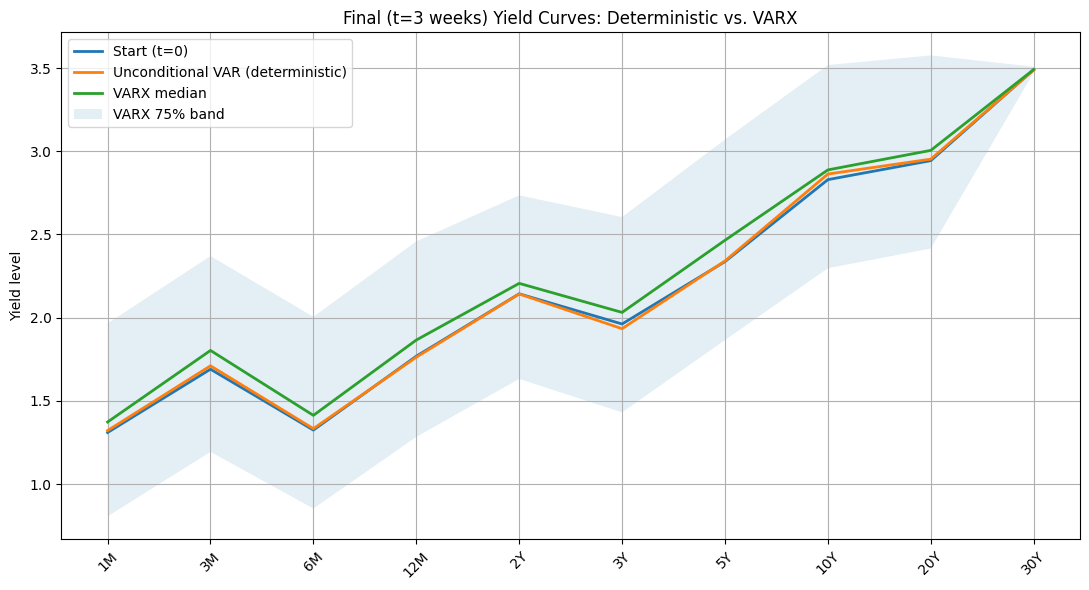

In [19]:
x = np.arange(m)
plt.figure(figsize=(11,6))
plt.plot(x, last_yield_levels, label='Start (t=0)', linewidth=2)
plt.plot(x, deterministic_final, label='Unconditional VAR (deterministic)', linewidth=2)
plt.plot(x, median_final_varx, label='VARX median', linewidth=2)
plt.fill_between(x, lower_varx, upper_varx, alpha=0.12, label='VARX 75% band')
plt.xticks(x, maturities, rotation=45)
plt.ylabel('Yield level')
plt.title('Final (t=3 weeks) Yield Curves: Deterministic vs. VARX')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()